# AE-TRAM: Autoencoder + Transformer Attention Mechanism
## Low-Rate DDoS Attack Detection — Binary & Multiclass Classification
### Dataset: CICIDS2017

**Framework Overview:**
```
CICIDS2017 CSV Files
       │
       ▼
  Preprocessing
  (Clean → Impute → Normalize)
       │
       ▼
  Attention-Enhanced Autoencoder (AE)
  [80 features → 32 encoded features]
       │
       ▼
  TRAM: Transformer Encoder
  (Multi-Head Self-Attention × 2 blocks)
       │
   ┌───┴───┐
   ▼       ▼
Binary  Multiclass
(2 cls)  (15 cls)
```

**Key difference from AE-CIAM:**  
AE-CIAM uses CNN Inception + scalar attention. AE-TRAM replaces this with a full **Transformer Encoder** (Multi-Head Self-Attention + LayerNorm + FFN), capturing global feature relationships across all encoded dimensions simultaneously.

---
**Paper Reference:** Najar & Naik, *Cluster Computing* (2025) — AE-CIAM

## 1. Install Dependencies

In [1]:
# Run once if not already installed
# !pip install tensorflow scikit-learn pandas numpy matplotlib seaborn glob2
print('All libraries assumed installed. Uncomment above line if needed.')

All libraries assumed installed. Uncomment above line if needed.


## 2. Import Libraries

In [2]:
import os
import glob
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    matthews_corrcoef, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print(f'Num GPUs available : {len(tf.config.list_physical_devices("GPU"))}')
print(f'Seed               : {SEED}')

TensorFlow version : 2.16.2
Num GPUs available : 1
Seed               : 42


## 3. Configuration — Hyperparameters

In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# DATASET CONFIGURATION  (exact column names as in CICIDS2017 CSV files)
# ═══════════════════════════════════════════════════════════════════════════
# CICIDS2017 comes as 8 separate CSV files (Monday–Friday).
# Place all CSVs in one folder and set DATA_FOLDER below.
DATA_FOLDER   = '/Users/omprasad/aeciam/data'           # ← UPDATE THIS PATH
LABEL_COL     = ' Label'                  # Note: leading space in original CSV

# Columns to DROP — identifiers, no predictive value (as per paper)
DROP_COLS = ['Flow ID', ' Timestamp', ' Source IP',
             ' Destination IP', ' Source Port']

# Known CICIDS2017 class distribution (Table 2 from paper)
CICIDS2017_CLASS_INFO = {
    'BENIGN'                 : 2272688,
    'DoS Hulk'               : 230124,
    'PortScan'               : 158930,
    'DDoS'                   : 128027,
    'DoS GoldenEye'          : 10293,
    'FTP-Patator'            : 7938,
    'SSH-Patator'            : 5897,
    'DoS slowloris'          : 5796,   # LDDoS
    'DoS Slowhttptest'       : 5499,   # LDDoS
    'Bot'                    : 1966,
    'Web Attack Brute Force' : 1507,
    'Web Attack XSS'         : 652,
    'Infiltration'           : 36,
    'Web Attack Sql Injection': 21,
    'Heartbleed'             : 11,
}
TOTAL_RECORDS_PAPER = 2_829_385  # After cleaning (paper Table 2)

# LDDoS classes (focus of paper)
LDDOS_CLASSES = ['DoS slowloris', 'DoS Slowhttptest']

# ═══════════════════════════════════════════════════════════════════════════
# AUTOENCODER HYPERPARAMETERS  (match paper Table 3)
# ═══════════════════════════════════════════════════════════════════════════
AE_HIDDEN_DIM   = 96       # First dense layer units (encoder)
AE_ENCODING_DIM = 32       # Bottleneck / latent space dimension (best per paper Table 5)
AE_EPOCHS       = 50       # Max epochs (early stopping at epoch 38 in paper)
AE_BATCH_SIZE   = 1024
AE_LR           = 0.001
AE_DROPOUT      = 0.3
AE_PATIENCE     = 10       # Early stopping patience
AE_LOSS         = 'mae'    # Mean Absolute Error

# ═══════════════════════════════════════════════════════════════════════════
# TRANSFORMER (TRAM) HYPERPARAMETERS
# ═══════════════════════════════════════════════════════════════════════════
TR_D_MODEL    = 64     # Token projection dimension
TR_NUM_HEADS  = 4      # Multi-head attention heads  (d_model must be divisible)
TR_FF_DIM     = 128    # Feed-forward inner dimension
TR_NUM_LAYERS = 2      # Stacked transformer encoder blocks
TR_DROPOUT    = 0.1
TR_EPOCHS     = 150    # Max epochs (early stopping monitors val_loss)
TR_BATCH_SIZE = 1024
TR_LR         = 0.0001 # Adam LR (same as paper's CIAM)
TR_PATIENCE   = 10

# ═══════════════════════════════════════════════════════════════════════════
# SPLIT CONFIG
# ═══════════════════════════════════════════════════════════════════════════
TEST_SIZE = 0.20   # 80/20 split (paper uses 20% holdout)
VAL_SIZE  = 0.10   # 10% of training set → validation

# Output directory
SAVE_DIR = './ae_tram_results'
os.makedirs(SAVE_DIR, exist_ok=True)

print('Configuration loaded successfully.')
print(f'  AE Encoding dim  : {AE_ENCODING_DIM}')
print(f'  Transformer heads: {TR_NUM_HEADS}')
print(f'  Transformer layers: {TR_NUM_LAYERS}')
print(f'  d_model          : {TR_D_MODEL}')

Configuration loaded successfully.
  AE Encoding dim  : 32
  Transformer heads: 4
  Transformer layers: 2
  d_model          : 64


## 4. CICIDS2017 Dataset

### Overview
The **CICIDS2017** dataset was built using the **NetFlowMeter** network traffic analyzer at the Canadian Institute for Cybersecurity. It captures **bi-directional flows** across **5 days** of simulated traffic.

| Property | Value |
|----------|-------|
| Total records (raw) | 2,830,743 |
| Total records (cleaned) | 2,829,385 |
| Total features | 80+ |
| Attack classes | 14 + BENIGN = **15** |
| Format | CSV (8 files, one per traffic session) |
| Label column | `' Label'` (leading space) |

### Daily CSV Files
| File | Day | Content |
|------|-----|----------|
| `Monday-WorkingHours.pcap_ISCX.csv` | Mon | BENIGN only |
| `Tuesday-WorkingHours.pcap_ISCX.csv` | Tue | FTP-Patator, SSH-Patator |
| `Wednesday-WorkingHours.pcap_ISCX.csv` | Wed | DoS Hulk, DoS GoldenEye, **DoS slowloris**, **DoS Slowhttptest**, Heartbleed |
| `Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv` | Thu AM | Web Attacks |
| `Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv` | Thu PM | Infiltration |
| `Friday-WorkingHours-Morning.pcap_ISCX.csv` | Fri AM | Bot |
| `Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv` | Fri PM | PortScan |
| `Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv` | Fri PM | DDoS |

### Class Distribution (After Cleaning — Table 2 from paper)
| Class | Count | % | Type |
|-------|-------|---|------|
| BENIGN | 2,272,688 | 80.286% | Normal |
| DoS Hulk | 230,124 | 8.129% | HDDoS |
| PortScan | 158,930 | 5.614% | Scan |
| DDoS | 128,027 | 4.523% | HDDoS |
| DoS GoldenEye | 10,293 | 0.364% | HDDoS |
| FTP-Patator | 7,938 | 0.280% | Brute Force |
| SSH-Patator | 5,897 | 0.208% | Brute Force |
| **DoS slowloris** | **5,796** | **0.205%** | **LDDoS** |
| **DoS Slowhttptest** | **5,499** | **0.194%** | **LDDoS** |
| Bot | 1,966 | 0.069% | Botnet |
| Web Attack Brute Force | 1,507 | 0.053% | Web |
| Web Attack XSS | 652 | 0.023% | Web |
| Infiltration | 36 | 0.001% | Infiltration |
| Web Attack Sql Injection | 21 | 0.001% | Web |
| Heartbleed | 11 | 0.000% | Exploit |

> **Note:** LDDoS classes (slowloris & Slowhttptest) represent only ~0.4% of data — severe class imbalance.

### Why CICIDS2017?
- **80+ features** vs NSL-KDD (42) and UNSW-NB15 (49)
- Covers **LDDoS attacks** — slowloris and Slowhttptest (critical for this paper)
- Organized into 8 sessions → real traffic diversity
- Supports **real-time detection** (metadata + payload)
- High class imbalance → tests robustness of the framework

## 5. Load CICIDS2017 Dataset (All CSV Files)

In [13]:
print("Loading dataset...")

# Getting all CSV files in the folder
csv_files = [f for f in os.listdir(DATA_FOLDER) if f.endswith(".csv")]

print("CSV files found:")
for f in csv_files:
    print(" -", f)

# Reading and concatenating all CSVs
df_list = []
for file in csv_files:
    file_path = os.path.join(DATA_FOLDER, file)
    temp_df = pd.read_csv(file_path, encoding="utf-8")
    df_list.append(temp_df)

raw_df = pd.concat(df_list, ignore_index=True)

print(f"\nDataset shape: {raw_df.shape}")

print("\nFirst few rows:")
display(raw_df.head())

print("\nDataset info:")
print(raw_df.info())

print("\nClass distribution:")
# leading space is due to the original column name in the dataset analysed during Data analysis phase by the team
print(raw_df[LABEL_COL].value_counts())

Loading dataset...
CSV files found:
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv

Dataset shape: (2830743, 79)

First few rows:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,166,1,1,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
1,60148,83,1,2,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
2,123,99947,1,1,48,48,48,48,48.0,0.0,...,40,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
3,123,37017,1,1,48,48,48,48,48.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
4,0,111161336,147,0,0,0,0,0,0.0,0.0,...,0,1753752.625,2123197.578,4822992,95,9463032.7,2657727.996,13600000,5700287,BENIGN



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow I

## 6. Exploratory Data Analysis (EDA)

In [14]:
# Strip whitespace from all column names
raw_df.columns = raw_df.columns.str.strip()
label_col = LABEL_COL.strip()   # 'Label' (no leading space after strip)

print('=== CLASS DISTRIBUTION (Raw) ===')
class_counts = raw_df[label_col].value_counts()
print(class_counts)
print(f'\nTotal classes : {len(class_counts)}')
print(f'Total records : {len(raw_df):,}')

=== CLASS DISTRIBUTION (Raw) ===
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Total classes : 15
Total records : 2,830,743


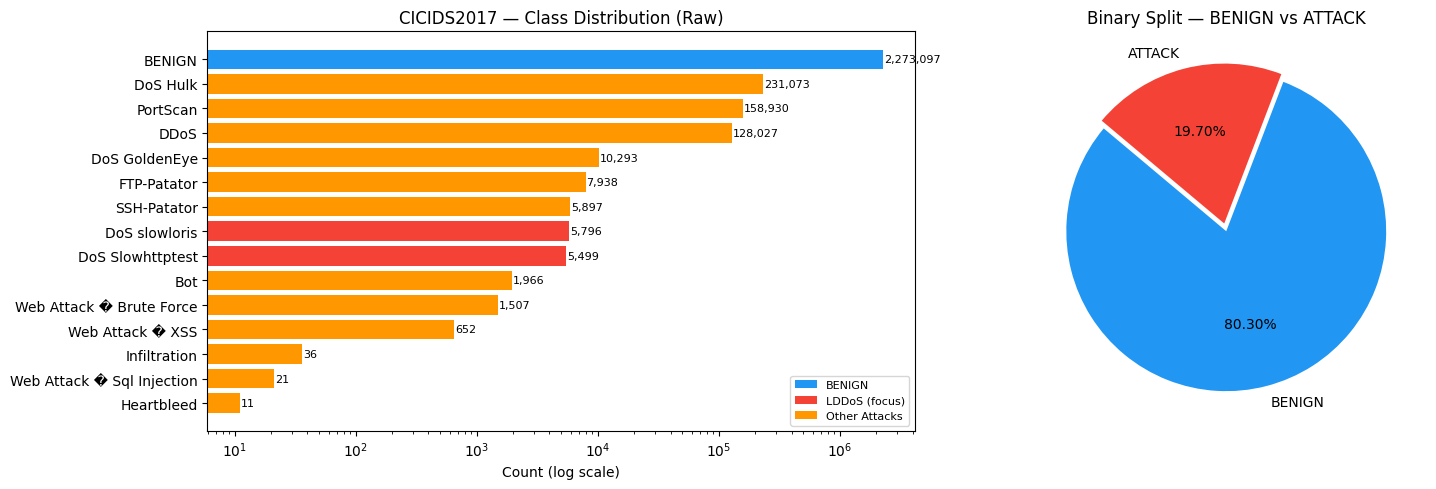

Plot saved.


In [15]:
# ── Visualise class distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
colors = ['#2196F3' if c == 'BENIGN' else
          '#F44336' if c in LDDOS_CLASSES else
          '#FF9800' for c in class_counts.index]
axes[0].barh(class_counts.index, class_counts.values, color=colors)
axes[0].set_xlabel('Count (log scale)')
axes[0].set_xscale('log')
axes[0].set_title('CICIDS2017 — Class Distribution (Raw)')
axes[0].invert_yaxis()
for i, v in enumerate(class_counts.values):
    axes[0].text(v * 1.02, i, f'{v:,}', va='center', fontsize=8)

# Pie chart (top-level benign vs attack)
benign_count = class_counts.get('BENIGN', 0)
attack_count = class_counts.sum() - benign_count
axes[1].pie([benign_count, attack_count],
            labels=['BENIGN', 'ATTACK'],
            autopct='%1.2f%%',
            colors=['#2196F3', '#F44336'],
            startangle=140,
            explode=[0, 0.05])
axes[1].set_title('Binary Split — BENIGN vs ATTACK')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2196F3', label='BENIGN'),
    Patch(facecolor='#F44336', label='LDDoS (focus)'),
    Patch(facecolor='#FF9800', label='Other Attacks'),
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

In [16]:
# ── Data types & missing values summary ──────────────────────────────────────
print('=== DATA TYPES ===')
print(raw_df.dtypes.value_counts())

print('\n=== NULL / NaN COUNTS (top 10 columns) ===')
null_counts = raw_df.isnull().sum()
print(null_counts[null_counts > 0].sort_values(ascending=False).head(10))

print('\n=== INF VALUE CHECK ===')
numeric_cols = raw_df.select_dtypes(include=[np.number]).columns
inf_cols = raw_df[numeric_cols].isin([np.inf, -np.inf]).sum()
print(inf_cols[inf_cols > 0])

=== DATA TYPES ===
int64      54
float64    24
object      1
Name: count, dtype: int64

=== NULL / NaN COUNTS (top 10 columns) ===
Flow Bytes/s    1358
dtype: int64

=== INF VALUE CHECK ===
Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64


## 7. Preprocessing

Following the **exact preprocessing pipeline** from the AE-CIAM paper (Section 4.3):

1. **Drop identifier columns** — Flow ID, Timestamp, Source/Dest IP (no predictive value)
2. **Remove constant features** — columns with identical values across all records
3. **Replace Inf → NaN** — ML models cannot process infinite values
4. **Impute NaN via Linear Regression** — splits into COLS_WONA and COLS_WNA, predicts missing values (preserves dataset integrity vs. row deletion)
5. **Remove duplicates** — improves data quality
6. **Min-Max Normalization** — scales all features to [0, 1]:

$$X_{normalized_{ij}} = \frac{X_{ij} - \min_j}{\max_j - \min_j}$$

7. **Label Encoding** — BENIGN=0, attack classes 1–14

In [17]:
def preprocess_cicids2017(df: pd.DataFrame,
                           label_col: str,
                           drop_cols: list) -> tuple:
    """
    Full preprocessing pipeline matching AE-CIAM paper Section 4.3.

    Returns:
        X_norm     : np.ndarray — normalized feature matrix
        y_multi    : np.ndarray — integer multiclass labels (0-14)
        y_binary   : np.ndarray — binary labels (0=BENIGN, 1=ATTACK)
        class_names: list of class name strings
        le         : fitted LabelEncoder
        feature_names: list of feature column names
    """
    df = df.copy()
    print('[STEP 1] Dropping identifier columns...')
    drop_existing = [c for c in drop_cols if c in df.columns]
    df.drop(columns=drop_existing, inplace=True)
    print(f'  Dropped: {drop_existing}')

    print('[STEP 2] Separating label...')
    y_raw = df[label_col].copy()
    df.drop(columns=[label_col], inplace=True)

    print('[STEP 3] Keeping numeric columns only...')
    df = df.select_dtypes(include=[np.number])
    print(f'  Numeric features: {df.shape[1]}')

    print('[STEP 4] Removing constant features...')
    n_before = df.shape[1]
    df = df.loc[:, df.nunique() > 1]
    print(f'  Removed {n_before - df.shape[1]} constant columns. Remaining: {df.shape[1]}')

    print('[STEP 5] Replacing Inf values with NaN...')
    n_inf = np.isinf(df.values).sum()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    print(f'  Replaced {n_inf:,} Inf values')

    print('[STEP 6] Imputing missing values (Linear Regression — paper method)...')
    # Split into features WITH and WITHOUT missing values (COLS_WNA / COLS_WONA)
    COLS_WONA = df.columns[df.isnull().sum() == 0].tolist()   # No missing
    COLS_WNA  = df.columns[df.isnull().sum() > 0].tolist()    # Has missing
    print(f'  COLS_WONA (no NaN) : {len(COLS_WONA)}')
    print(f'  COLS_WNA  (has NaN): {len(COLS_WNA)}')

    if COLS_WNA:
        # Use LR trained on non-missing rows to fill NaN (preserves data integrity)
        for col in COLS_WNA:
            mask_notna = df[col].notna()
            mask_isna  = df[col].isna()
            if mask_isna.sum() == 0:
                continue
            X_fit = df.loc[mask_notna, COLS_WONA]
            y_fit = df.loc[mask_notna, col]
            lr = LinearRegression()
            try:
                lr.fit(X_fit, y_fit)
                df.loc[mask_isna, col] = lr.predict(df.loc[mask_isna, COLS_WONA])
            except Exception:
                # Fallback: median imputation
                df[col].fillna(df[col].median(), inplace=True)
    print(f'  Remaining NaN: {df.isnull().sum().sum()}')

    print('[STEP 7] Removing duplicate records...')
    combined = df.copy()
    combined['__label__'] = y_raw.values
    n_before = len(combined)
    combined.drop_duplicates(inplace=True)
    y_raw = combined['__label__']
    df = combined.drop(columns=['__label__'])
    print(f'  Removed {n_before - len(df):,} duplicates. Remaining: {len(df):,}')

    feature_names = df.columns.tolist()
    print(f'[INFO] Final feature count: {len(feature_names)}')

    print('[STEP 8] Label encoding...')
    le = LabelEncoder()
    y_multi = le.fit_transform(y_raw)
    class_names = list(le.classes_)
    print(f'  Classes ({len(class_names)}): {class_names}')

    # Binary: 0=BENIGN, 1=ATTACK
    benign_idx = list(le.classes_).index('BENIGN') if 'BENIGN' in le.classes_ else 0
    y_binary = (y_multi != benign_idx).astype(np.int32)

    print('[STEP 9] Min-Max Normalization → [0, 1]...')
    scaler = MinMaxScaler()
    X_norm = scaler.fit_transform(df.values.astype(np.float32))

    print(f'\n[DONE] Final shape: X={X_norm.shape}, y_multi={y_multi.shape}')
    print(f'  Benign : {(y_binary==0).sum():,} ({(y_binary==0).mean()*100:.2f}%)')
    print(f'  Attack : {(y_binary==1).sum():,} ({(y_binary==1).mean()*100:.2f}%)')

    return X_norm, y_multi, y_binary, class_names, le, feature_names


# ── Run preprocessing ─────────────────────────────────────────────────────────
X, y_multi, y_binary, class_names, label_enc, feature_names = preprocess_cicids2017(
    raw_df, label_col, DROP_COLS
)
n_classes = len(class_names)
input_dim = X.shape[1]
print(f'\nInput dimension (features): {input_dim}')
print(f'Number of classes         : {n_classes}')

[STEP 1] Dropping identifier columns...
  Dropped: []
[STEP 2] Separating label...
[STEP 3] Keeping numeric columns only...
  Numeric features: 78
[STEP 4] Removing constant features...
  Removed 8 constant columns. Remaining: 70
[STEP 5] Replacing Inf values with NaN...
  Replaced 4,376 Inf values
[STEP 6] Imputing missing values (Linear Regression — paper method)...
  COLS_WONA (no NaN) : 68
  COLS_WNA  (has NaN): 2
  Remaining NaN: 0
[STEP 7] Removing duplicate records...
  Removed 308,381 duplicates. Remaining: 2,522,362
[INFO] Final feature count: 70
[STEP 8] Label encoding...
  Classes (15): ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']
[STEP 9] Min-Max Normalization → [0, 1]...

[DONE] Final shape: X=(2522362, 70), y_multi=(2522362,)
  Benign : 2,096,484 (83.12%)
  Attack : 425,878 (16.

In [18]:
# ── Distribution after cleaning (match paper Table 2) ───────────────────────
print('=== CLEANED DATASET DISTRIBUTION (match paper Table 2) ===')
unique, counts = np.unique(y_multi, return_counts=True)
dist_df = pd.DataFrame({
    'Class'     : [class_names[i] for i in unique],
    'Count'     : counts,
    '% Dist'    : (counts / counts.sum() * 100).round(3),
    'Type'      : ['LDDoS' if class_names[i] in LDDOS_CLASSES
                   else 'BENIGN' if class_names[i] == 'BENIGN'
                   else 'Other Attack'
                   for i in unique]
})
dist_df = dist_df.sort_values('Count', ascending=False).reset_index(drop=True)
print(dist_df.to_string(index=False))
print(f'\nTotal records: {counts.sum():,}')

=== CLEANED DATASET DISTRIBUTION (match paper Table 2) ===
                     Class   Count  % Dist         Type
                    BENIGN 2096484  83.116       BENIGN
                  DoS Hulk  172849   6.853 Other Attack
                      DDoS  128016   5.075 Other Attack
                  PortScan   90819   3.601 Other Attack
             DoS GoldenEye   10286   0.408 Other Attack
               FTP-Patator    5933   0.235 Other Attack
             DoS slowloris    5385   0.213        LDDoS
          DoS Slowhttptest    5228   0.207        LDDoS
               SSH-Patator    3219   0.128 Other Attack
                       Bot    1953   0.077 Other Attack
  Web Attack � Brute Force    1470   0.058 Other Attack
          Web Attack � XSS     652   0.026 Other Attack
              Infiltration      36   0.001 Other Attack
Web Attack � Sql Injection      21   0.001 Other Attack
                Heartbleed      11   0.000 Other Attack

Total records: 2,522,362


## 8. Train / Validation / Test Split

In [19]:
# ── 80/20 train-test split → then 10% of train → validation ─────────────────
X_tr, X_test, ym_tr, ym_test, yb_tr, yb_test = train_test_split(
    X, y_multi, y_binary,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_multi      # Preserve class ratios (important for imbalanced data)
)

X_tr, X_val, ym_tr, ym_val, yb_tr, yb_val = train_test_split(
    X_tr, ym_tr, yb_tr,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=ym_tr
)

print(f'Training   set : {X_tr.shape[0]:>10,} samples ({X_tr.shape[0]/len(X)*100:.1f}%)')
print(f'Validation set : {X_val.shape[0]:>10,} samples ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test       set : {X_test.shape[0]:>10,} samples ({X_test.shape[0]/len(X)*100:.1f}%)')

Training   set :  1,816,100 samples (72.0%)
Validation set :    201,789 samples (8.0%)
Test       set :    504,473 samples (20.0%)


## 9. Attention-Enhanced Autoencoder (AE)

Architecture (matches paper Section 5.1):

```
Input (80 features)
    │
    ├── Dense(96, ReLU)  ← Encoder Layer 1
    ├── BatchNormalization
    ├── Dropout(0.3)
    ├── Dense(32, ReLU)  ← Bottleneck (encoding_dim)
    ├── Dropout(0.3)
    │
    ├── Softmax Attention  ← attention weights A = softmax(W·Z_encoded)
    ├── Multiply(A ⊙ Z_encoded)  → Z_attended
    │
    ├── Dropout(0.3)         ← Decoder
    ├── Dense(96, tanh)
    └── Dense(input_dim, sigmoid)  → Reconstructed output
```

**Loss:** MAE = (1/N) Σ |X_i − X̂_i|

**Optimizer:** Adam (lr=0.001)

In [20]:
def build_autoencoder(input_dim: int,
                      encoding_dim: int = 32,
                      hidden_dim: int = 96,
                      dropout: float = 0.3) -> tuple:
    """
    Attention-Enhanced Autoencoder — paper Section 5.1–5.4

    Encoder:  input → Dense(96,ReLU) → BN → Dropout → Dense(32,ReLU) → Dropout
    Attention: softmax(W·Z) ⊙ Z  → attended encoding
    Decoder:  attended → Dropout → Dense(96,tanh) → Dense(input_dim,sigmoid)

    Returns: (autoencoder, encoder) both as keras.Model
    """
    inp = Input(shape=(input_dim,), name='ae_input')

    # ── ENCODER ──────────────────────────────────────────────────────────────
    # Z = max(0, W1·X + b1)   — Eq. from paper
    x = layers.Dense(hidden_dim, activation='relu', name='enc_dense1')(inp)
    x = layers.BatchNormalization(name='enc_bn')(x)
    x = layers.Dropout(dropout, name='enc_drop1')(x)
    # Z_encoded = max(0, W2·Z + b2)
    encoded = layers.Dense(encoding_dim, activation='relu', name='enc_bottleneck')(x)
    encoded = layers.Dropout(dropout, name='enc_drop2')(encoded)

    # ── ATTENTION MECHANISM ───────────────────────────────────────────────────
    # A = softmax(W_att · Z_encoded + b_att)     — Eq. from paper
    attn_weights = layers.Dense(encoding_dim, activation='softmax',
                                name='attn_weights')(encoded)
    # Z_attended = A ⊙ Z_encoded
    attended = layers.Multiply(name='attended_encoding')([attn_weights, encoded])

    # ── DECODER ───────────────────────────────────────────────────────────────
    # X_reconstructed = tanh(W_dec · Z_attended + b_dec)
    d = layers.Dropout(dropout, name='dec_drop')(attended)
    d = layers.Dense(hidden_dim, activation='tanh', name='dec_dense1')(d)
    decoded = layers.Dense(input_dim, activation='sigmoid', name='ae_output')(d)

    # ── MODELS ────────────────────────────────────────────────────────────────
    autoencoder = Model(inp, decoded, name='AE_Attention')
    encoder     = Model(inp, attended, name='Encoder_Attention')

    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=AE_LR),
        loss='mae'    # Mean Absolute Error — paper Table 3
    )
    return autoencoder, encoder


ae_model, encoder_model = build_autoencoder(input_dim, AE_ENCODING_DIM, AE_HIDDEN_DIM)
ae_model.summary()
print(f'\nTotal AE parameters: {ae_model.count_params():,}')

2026-02-21 18:03:41.919643: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-02-21 18:03:41.919847: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-02-21 18:03:41.920102: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-02-21 18:03:41.920385: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-21 18:03:41.920796: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "AE_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ae_input            │ (None, 70)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_dense1 (Dense)  │ (None, 96)        │      6,816 │ ae_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_bn              │ (None, 96)        │        384 │ enc_dense1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_drop1 (Dropout) │ (None, 96)        │          0 │ enc_bn[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_bottleneck      │ (None, 32)        │      3,104 │ enc_drop1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_drop2 (Dropout) │ (None, 32)        │          0 │ enc_bottleneck[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_weights        │ (None, 32)        │      1,056 │ enc_drop2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attended_encoding   │ (None, 32)        │          0 │ attn_weights[0][… │
│ (Multiply)          │                   │            │ enc_drop2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_drop (Dropout)  │ (None, 32)        │          0 │ attended_encodin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_dense1 (Dense)  │ (None, 96)        │      3,168 │ dec_drop[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ae_output (Dense)   │ (None, 70)        │      6,790 │ dec_dense1[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,318 (83.27 KB)

 Trainable params: 21,126 (82.52 KB)

 Non-trainable params: 192 (768.00 B)


Total AE parameters: 21,318


### 9.1 Train the Autoencoder

In [21]:
ae_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=AE_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

print('Training Attention-Enhanced Autoencoder...')
print(f'  Epochs     : {AE_EPOCHS}')
print(f'  Batch size : {AE_BATCH_SIZE}')
print(f'  LR         : {AE_LR}')
print(f'  Loss       : MAE (Mean Absolute Error)')

t0 = time.time()
ae_history = ae_model.fit(
    X_tr, X_tr,                        # Reconstruction: input == target
    validation_data=(X_val, X_val),
    epochs=AE_EPOCHS,
    batch_size=AE_BATCH_SIZE,
    callbacks=ae_callbacks,
    verbose=1
)
ae_train_time = time.time() - t0
print(f'\nAE Training time: {ae_train_time:.2f}s')

best_epoch = np.argmin(ae_history.history['val_loss']) + 1
best_val_loss = min(ae_history.history['val_loss'])
best_train_loss = ae_history.history['loss'][best_epoch - 1]
print(f'Best epoch       : {best_epoch}')
print(f'Best train loss  : {best_train_loss:.4f}')
print(f'Best val loss    : {best_val_loss:.4f}')
# Paper reports: train loss=0.1051, val loss=0.0731 at epoch 38

Training Attention-Enhanced Autoencoder...
  Epochs     : 50
  Batch size : 1024
  LR         : 0.001
  Loss       : MAE (Mean Absolute Error)
Epoch 1/50


2026-02-21 18:03:50.270655: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1774/1774 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - loss: 0.0951 - val_loss: 0.0208 - learning_rate: 0.0010
Epoch 2/50
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - loss: 0.0211 - val_loss: 0.0187 - learning_rate: 0.0010
Epoch 3/50
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 0.0188 - val_loss: 0.0191 - learning_rate: 0.0010
Epoch 4/50
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - loss: 0.0169 - val_loss: 0.0172 - learning_rate: 0.0010
Epoch 5/50
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0160 - val_loss: 0.0171 - learning_rate: 0.0010
Epoch 6/50
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0145 - val_loss: 0.0135 - learning_rate: 0.0010
Epoch 7/50
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0122 - val_loss: 0.0135 - learning_rate: 0.0010
Epoch 8/50
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0121 - val_loss: 0.0138 - learning_rate: 0.0010
Epoch 9/50
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 0.0120 - val_loss: 0.0134 - learnin

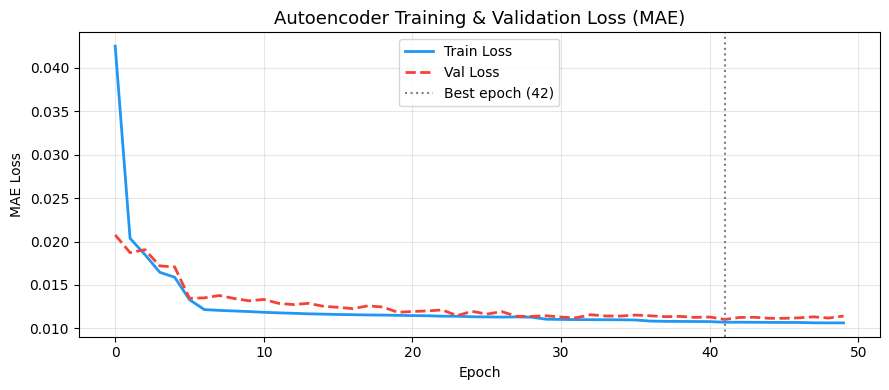

In [22]:
# ── Autoencoder loss plot (Figure 9 from paper) ──────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ae_history.history['loss'],     label='Train Loss', color='#2196F3', lw=2)
ax.plot(ae_history.history['val_loss'], label='Val Loss',   color='#F44336', lw=2, ls='--')
ax.axvline(best_epoch - 1, color='gray', ls=':', lw=1.5, label=f'Best epoch ({best_epoch})')
ax.set_title('Autoencoder Training & Validation Loss (MAE)', fontsize=13)
ax.set_xlabel('Epoch'); ax.set_ylabel('MAE Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'ae_loss.png'), dpi=150, bbox_inches='tight')
plt.show()

### 9.2 Extract Encoded (Latent) Features

In [23]:
print('Extracting encoded features from AE bottleneck layer...')
t0 = time.time()
X_tr_enc   = encoder_model.predict(X_tr,   batch_size=AE_BATCH_SIZE, verbose=0)
X_val_enc  = encoder_model.predict(X_val,  batch_size=AE_BATCH_SIZE, verbose=0)
X_test_enc = encoder_model.predict(X_test, batch_size=AE_BATCH_SIZE, verbose=0)
print(f'Encoding time: {time.time()-t0:.2f}s')
print(f'  Original features : {input_dim}')
print(f'  Encoded features  : {X_tr_enc.shape[1]}  (dimensionality reduced)')
print(f'  Train encoded shape: {X_tr_enc.shape}')
print(f'  Test  encoded shape: {X_test_enc.shape}')

Extracting encoded features from AE bottleneck layer...
Encoding time: 4.11s
  Original features : 70
  Encoded features  : 32  (dimensionality reduced)
  Train encoded shape: (1816100, 32)
  Test  encoded shape: (504473, 32)


### 9.3 AE Latent Space vs PCA — Comparison
*(Replicates Figures 7 & 8 from paper — shows AE captures better cluster separation)*

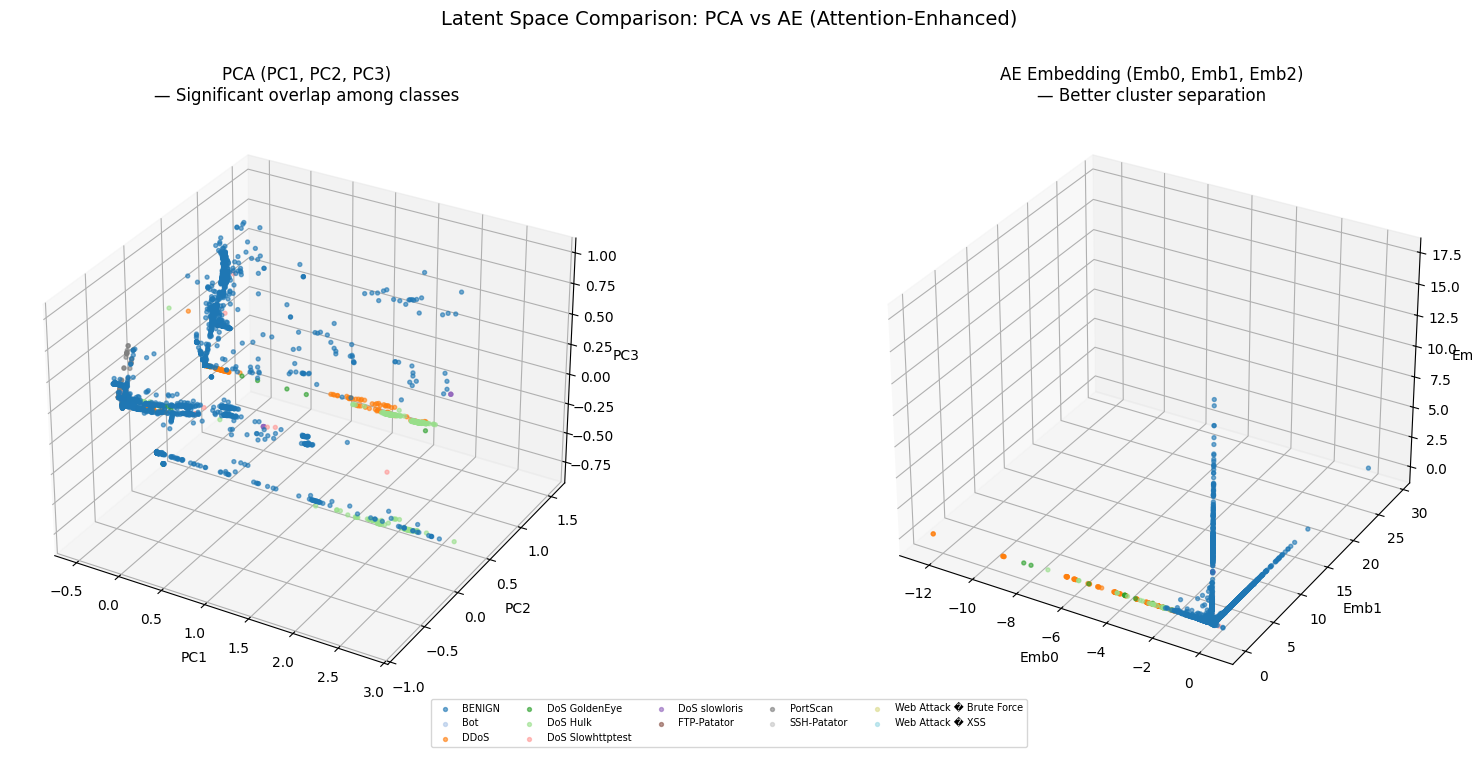

AE embeddings reveal distinctly better cluster separation than PCA.


In [24]:
from mpl_toolkits.mplot3d import Axes3D

# Sample for visualization (use stratified sample to keep all classes)
VIZ_N = min(5000, len(X_val_enc))
idx_viz = np.random.choice(len(X_val_enc), VIZ_N, replace=False)

X_viz_enc = X_val_enc[idx_viz]
X_viz_raw = X_val[idx_viz]
y_viz     = ym_val[idx_viz]

# PCA on raw features
pca = PCA(n_components=13)
X_viz_pca = pca.fit_transform(X_viz_raw)

# Colour palette
palette = plt.cm.tab20(np.linspace(0, 1, n_classes))

fig = plt.figure(figsize=(18, 7))
fig.suptitle('Latent Space Comparison: PCA vs AE (Attention-Enhanced)', fontsize=14, y=1.01)

# PCA — first 3 components
ax1 = fig.add_subplot(121, projection='3d')
for i, cname in enumerate(class_names):
    mask = y_viz == i
    if mask.sum() == 0: continue
    ax1.scatter(X_viz_pca[mask, 0], X_viz_pca[mask, 1], X_viz_pca[mask, 2],
                s=8, alpha=0.6, color=palette[i], label=cname)
ax1.set_title('PCA (PC1, PC2, PC3)\n— Significant overlap among classes')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2'); ax1.set_zlabel('PC3')

# AE — first 3 embeddings
ax2 = fig.add_subplot(122, projection='3d')
for i, cname in enumerate(class_names):
    mask = y_viz == i
    if mask.sum() == 0: continue
    ax2.scatter(X_viz_enc[mask, 0], X_viz_enc[mask, 1], X_viz_enc[mask, 2],
                s=8, alpha=0.6, color=palette[i], label=cname)
ax2.set_title('AE Embedding (Emb0, Emb1, Emb2)\n— Better cluster separation')
ax2.set_xlabel('Emb0'); ax2.set_ylabel('Emb1'); ax2.set_zlabel('Emb2')

handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5,
           fontsize=7, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'pca_vs_ae_3d.png'), dpi=150, bbox_inches='tight')
plt.show()
print('AE embeddings reveal distinctly better cluster separation than PCA.')

## 10. TRAM — Transformer Attention Mechanism Classifier

**AE-TRAM replaces** AE-CIAM's *CNN Inception + scalar attention* with a full **Transformer Encoder**:

```
Encoded features (32,)          ← AE bottleneck output
        │
   Reshape(32, 1)                ← treat each feature as a token
        │
   Dense(64)                     ← project to d_model=64
        │
  + Positional Embedding(32,64)  ← learned position info
        │
   ┌─────────────────────┐ × 2 blocks
   │  MultiHeadAttention │  (4 heads, key_dim=16)
   │  Add & LayerNorm    │
   │  FFN(128) → Dense(64)│
   │  Add & LayerNorm    │
   └─────────────────────┘
        │
  GlobalAveragePooling1D          ← (batch, 64)
        │
   Dense(64, relu) → Dense(32, relu)
        │
   ┌────┴────┐
   ▼         ▼
Dense(15,   Dense(1,
softmax)   sigmoid)
Multiclass  Binary
```

In [25]:
class TransformerEncoderBlock(layers.Layer):
    """
    Single Transformer Encoder block:
      1. Multi-Head Self-Attention
      2. Add & LayerNorm
      3. Position-wise Feed-Forward Network
      4. Add & LayerNorm
    """
    def __init__(self, d_model: int, num_heads: int,
                 ff_dim: int, dropout: float = 0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha    = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=d_model // num_heads,
            dropout=dropout
        )
        # Feed-Forward Network: Dense(ff_dim,relu) → Dense(d_model)
        self.ffn    = keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(d_model)
        ], name='ffn')
        self.norm1  = layers.LayerNormalization(epsilon=1e-6)
        self.norm2  = layers.LayerNormalization(epsilon=1e-6)
        self.drop1  = layers.Dropout(dropout)
        self.drop2  = layers.Dropout(dropout)

    def call(self, x, training=False):
        # ── Multi-Head Self-Attention + residual ──────────────────────────────
        attn_out = self.mha(x, x, training=training)    # Q=K=V=x (self-attention)
        attn_out = self.drop1(attn_out, training=training)
        x = self.norm1(x + attn_out)                    # Add & Norm

        # ── Feed-Forward + residual ───────────────────────────────────────────
        ffn_out  = self.ffn(x)
        ffn_out  = self.drop2(ffn_out, training=training)
        x = self.norm2(x + ffn_out)                     # Add & Norm
        return x

    def get_config(self):
        config = super().get_config()
        return config


def build_tram(encoding_dim: int,
               n_classes: int,
               d_model: int    = 64,
               num_heads: int  = 4,
               ff_dim: int     = 128,
               num_layers: int = 2,
               dropout: float  = 0.1,
               task: str       = 'multi') -> keras.Model:
    """
    Transformer Attention Mechanism (TRAM) Classifier.

    task: 'multi'  → softmax output (n_classes),  loss=categorical_crossentropy
          'binary' → sigmoid output (1),           loss=binary_crossentropy
    """
    inp = Input(shape=(encoding_dim,), name='tram_input')

    # Reshape: (batch, encoding_dim) → (batch, encoding_dim, 1) — each feature = token
    x = layers.Reshape((encoding_dim, 1), name='token_reshape')(inp)

    # Project tokens to d_model dimension: (batch, encoding_dim, d_model)
    x = layers.Dense(d_model, name='token_projection')(x)

    # Learned Positional Embedding
    positions = tf.range(start=0, limit=encoding_dim, delta=1)
    pos_emb   = layers.Embedding(input_dim=encoding_dim,
                                  output_dim=d_model,
                                  name='positional_embedding')(positions)
    x = x + pos_emb    # (batch, encoding_dim, d_model)
    x = layers.Dropout(dropout)(x)

    # Stack Transformer Encoder Blocks
    for i in range(num_layers):
        x = TransformerEncoderBlock(
            d_model=d_model, num_heads=num_heads,
            ff_dim=ff_dim, dropout=dropout,
            name=f'transformer_block_{i}'
        )(x)

    # Global Average Pooling → (batch, d_model)
    x = layers.GlobalAveragePooling1D(name='global_avg_pool')(x)
    x = layers.Dropout(dropout)(x)

    # Classification Head
    x = layers.Dense(64, activation='relu', name='cls_head_1')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(32, activation='relu', name='cls_head_2')(x)

    # Output
    if task == 'binary':
        out  = layers.Dense(1, activation='sigmoid', name='binary_output')(x)
        loss = 'binary_crossentropy'
    else:
        out  = layers.Dense(n_classes, activation='softmax', name='multi_output')(x)
        loss = 'categorical_crossentropy'

    model = Model(inp, out, name=f'TRAM_{task}')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=TR_LR),
        loss=loss,
        metrics=['accuracy']
    )
    return model


print('TransformerEncoderBlock and build_tram defined successfully.')

TransformerEncoderBlock and build_tram defined successfully.


## 11. TRAM — Multiclass Classification (15 Classes)

In [26]:
# One-hot encode labels for multiclass
ym_tr_oh   = to_categorical(ym_tr,   n_classes)
ym_val_oh  = to_categorical(ym_val,  n_classes)
ym_test_oh = to_categorical(ym_test, n_classes)

# Build model
tram_multi = build_tram(
    encoding_dim=AE_ENCODING_DIM,
    n_classes=n_classes,
    d_model=TR_D_MODEL,
    num_heads=TR_NUM_HEADS,
    ff_dim=TR_FF_DIM,
    num_layers=TR_NUM_LAYERS,
    dropout=TR_DROPOUT,
    task='multi'
)
tram_multi.summary()
print(f'\nTotal TRAM (multi) parameters: {tram_multi.count_params():,}')

Model: "TRAM_multi"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tram_input (InputLayer)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_reshape (Reshape)         │ (None, 32, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_projection (Dense)        │ (None, 32, 64)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_0             │ (None, 32, 64)         │        33,472 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 32, 64)         │        33,472 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cls_head_1 (Dense)              │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cls_head_2 (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multi_output (Dense)            │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,807 (288.31 KB)

 Trainable params: 73,807 (288.31 KB)

 Non-trainable params: 0 (0.00 B)


Total TRAM (multi) parameters: 73,807


In [27]:
tram_callbacks = [
    EarlyStopping(monitor='val_loss', patience=TR_PATIENCE,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-7, verbose=1)
]

print('Training TRAM — Multiclass...')
t0 = time.time()
hist_multi = tram_multi.fit(
    X_tr_enc, ym_tr_oh,
    validation_data=(X_val_enc, ym_val_oh),
    epochs=TR_EPOCHS,
    batch_size=TR_BATCH_SIZE,
    callbacks=tram_callbacks,
    verbose=1
)
multi_train_time = time.time() - t0
print(f'\nMulticlass Training time: {multi_train_time:.2f}s')

Training TRAM — Multiclass...
Epoch 1/150
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 154s 84ms/step - accuracy: 0.7944 - loss: 0.7505 - val_accuracy: 0.9283 - val_loss: 0.2501 - learning_rate: 1.0000e-04
Epoch 2/150
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 193s 109ms/step - accuracy: 0.8959 - loss: 0.3922 - val_accuracy: 0.8808 - val_loss: 0.7034 - learning_rate: 1.0000e-04
Epoch 3/150
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 178s 100ms/step - accuracy: 0.8011 - loss: 0.9744 - val_accuracy: 0.9035 - val_loss: 0.6970 - learning_rate: 1.0000e-04
Epoch 4/150
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 169s 95ms/step - accuracy: 0.8145 - loss: 1.1680 - val_accuracy: 0.8687 - val_loss: 0.8505 - learning_rate: 1.0000e-04
Epoch 5/150
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 169s 95ms/step - accuracy: 0.8188 - loss: 1.2725 - val_accuracy: 0.8900 - val_loss: 1.0582 - learning_rate: 1.0000e-04
Epoch 6/150
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8262 - loss: 1.4043
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.9999998736893

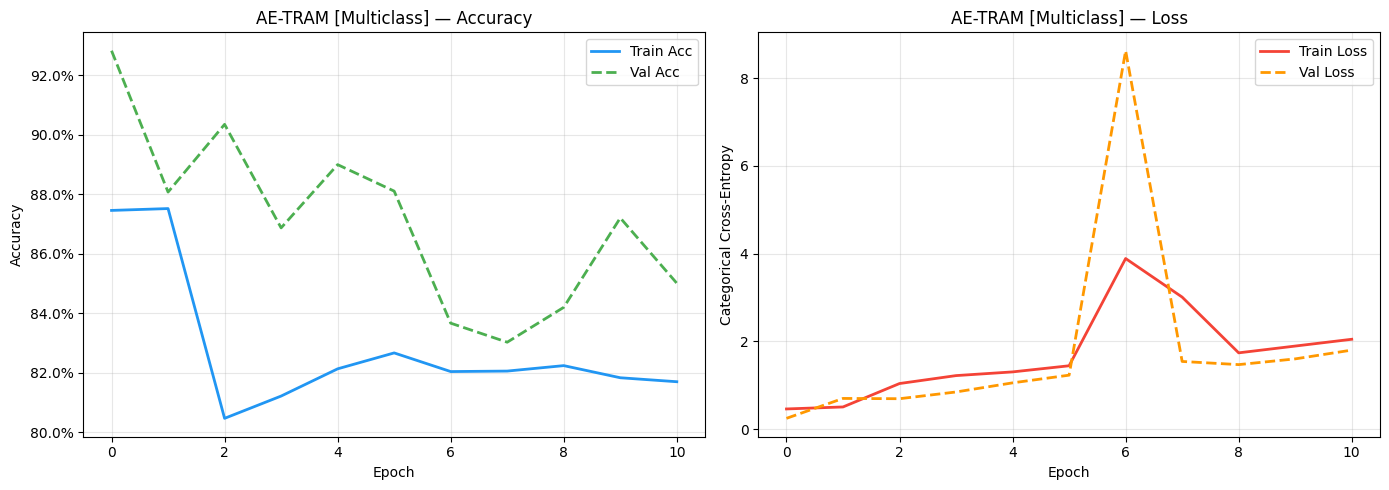

In [28]:
# ── Training curves — Multiclass ──────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(hist_multi.history['accuracy'],     label='Train Acc', color='#2196F3', lw=2)
ax1.plot(hist_multi.history['val_accuracy'], label='Val Acc',   color='#4CAF50', lw=2, ls='--')
ax1.set_title('AE-TRAM [Multiclass] — Accuracy', fontsize=12)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

ax2.plot(hist_multi.history['loss'],     label='Train Loss', color='#F44336', lw=2)
ax2.plot(hist_multi.history['val_loss'], label='Val Loss',   color='#FF9800', lw=2, ls='--')
ax2.set_title('AE-TRAM [Multiclass] — Loss', fontsize=12)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Categorical Cross-Entropy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'tram_multi_training.png'), dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ── Evaluate on test set — Multiclass ────────────────────────────────────────
print('Evaluating TRAM on test set [Multiclass]...')
t0 = time.time()
raw_preds_multi = tram_multi.predict(X_test_enc, batch_size=TR_BATCH_SIZE, verbose=0)
inf_time_multi  = (time.time() - t0) / len(X_test_enc)

y_pred_multi = np.argmax(raw_preds_multi, axis=1)

acc_m  = accuracy_score(ym_test, y_pred_multi)
prec_m = precision_score(ym_test, y_pred_multi, average='weighted', zero_division=0)
rec_m  = recall_score(ym_test, y_pred_multi, average='weighted', zero_division=0)
f1_m   = f1_score(ym_test, y_pred_multi, average='weighted', zero_division=0)
mcc_m  = matthews_corrcoef(ym_test, y_pred_multi)

# Test loss
test_loss_m = tram_multi.evaluate(X_test_enc, ym_test_oh,
                                   batch_size=TR_BATCH_SIZE, verbose=0)[0]

print('\n' + '='*58)
print('  AE-TRAM [MULTICLASS] — Test Results')
print('='*58)
print(f'  Accuracy              : {acc_m*100:.4f}%')
print(f'  Precision (weighted)  : {prec_m*100:.4f}%')
print(f'  Recall    (weighted)  : {rec_m*100:.4f}%')
print(f'  F1-Score  (weighted)  : {f1_m*100:.4f}%')
print(f'  MCC                   : {mcc_m:.4f}')
print(f'  Test Loss             : {test_loss_m:.4f}')
print(f'  Inference time/sample : {inf_time_multi:.6f}s')
print('='*58)

print('\nPer-Class Classification Report:')
print(classification_report(ym_test, y_pred_multi,
                             target_names=class_names, zero_division=0))

Evaluating TRAM on test set [Multiclass]...

  AE-TRAM [MULTICLASS] — Test Results
  Accuracy              : 92.7830%
  Precision (weighted)  : 92.4777%
  Recall    (weighted)  : 92.7830%
  F1-Score  (weighted)  : 92.4425%
  MCC                   : 0.7624
  Test Loss             : 0.2506
  Inference time/sample : 0.000018s

Per-Class Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       0.97      0.97      0.97    419297
                       Bot       0.00      0.00      0.00       391
                      DDoS       0.72      0.75      0.73     25603
             DoS GoldenEye       0.00      0.00      0.00      2057
                  DoS Hulk       0.92      0.80      0.85     34570
          DoS Slowhttptest       0.00      0.00      0.00      1046
             DoS slowloris       0.00      0.00      0.00      1077
               FTP-Patator       0.00      0.00      0.00      1187
                Heartbleed  

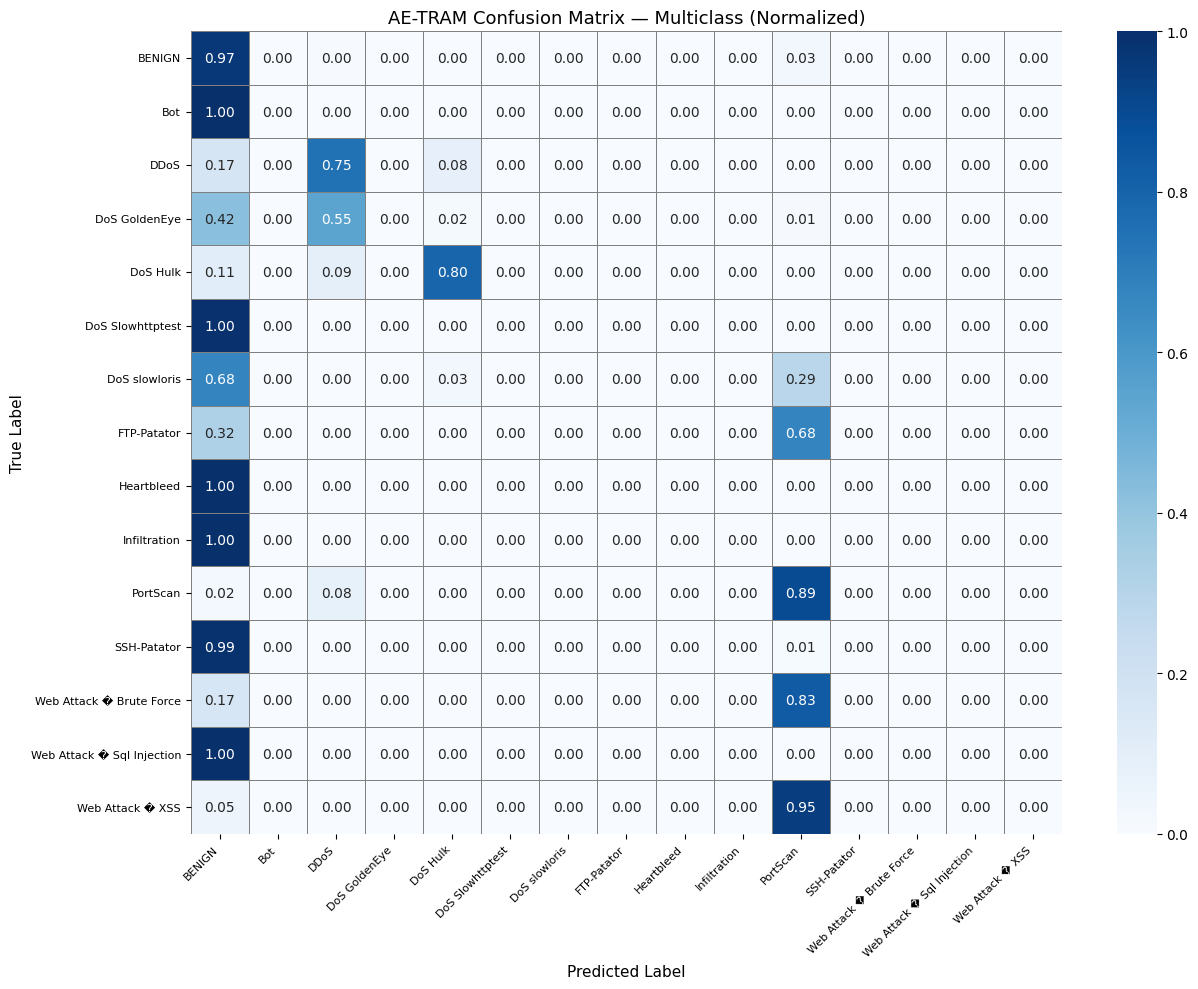

In [30]:
# ── Confusion Matrix — Multiclass ─────────────────────────────────────────────
cm_multi = confusion_matrix(ym_test, y_pred_multi)
cm_norm  = cm_multi.astype(float) / cm_multi.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            linewidths=0.5, linecolor='gray')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('AE-TRAM Confusion Matrix — Multiclass (Normalized)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'cm_multiclass.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. TRAM — Binary Classification (BENIGN vs ATTACK)

In [31]:
# Build binary TRAM model
tram_binary = build_tram(
    encoding_dim=AE_ENCODING_DIM,
    n_classes=2,
    d_model=TR_D_MODEL,
    num_heads=TR_NUM_HEADS,
    ff_dim=TR_FF_DIM,
    num_layers=TR_NUM_LAYERS,
    dropout=TR_DROPOUT,
    task='binary'
)
tram_binary.summary()
print(f'\nTotal TRAM (binary) parameters: {tram_binary.count_params():,}')

Model: "TRAM_binary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tram_input (InputLayer)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_reshape (Reshape)         │ (None, 32, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_projection (Dense)        │ (None, 32, 64)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_1 (Add)                     │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_0             │ (None, 32, 64)         │        33,472 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 32, 64)         │        33,472 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cls_head_1 (Dense)              │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cls_head_2 (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ binary_output (Dense)           │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,345 (286.50 KB)

 Trainable params: 73,345 (286.50 KB)

 Non-trainable params: 0 (0.00 B)


Total TRAM (binary) parameters: 73,345


In [32]:
print('Training TRAM — Binary...')
t0 = time.time()
hist_binary = tram_binary.fit(
    X_tr_enc,  yb_tr,
    validation_data=(X_val_enc, yb_val),
    epochs=TR_EPOCHS,
    batch_size=TR_BATCH_SIZE,
    callbacks=tram_callbacks,
    verbose=1
)
binary_train_time = time.time() - t0
print(f'\nBinary Training time: {binary_train_time:.2f}s')

Training TRAM — Binary...
Epoch 1/150
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 147s 81ms/step - accuracy: 0.8291 - loss: 0.3925 - val_accuracy: 0.9505 - val_loss: 0.1339 - learning_rate: 1.0000e-04
Epoch 2/150
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 160s 90ms/step - accuracy: 0.9323 - loss: 0.1755 - val_accuracy: 0.9295 - val_loss: 0.1917 - learning_rate: 1.0000e-04
Epoch 3/150
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 187s 106ms/step - accuracy: 0.9233 - loss: 0.2058 - val_accuracy: 0.9326 - val_loss: 0.1779 - learning_rate: 1.0000e-04
Epoch 4/150
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 181s 102ms/step - accuracy: 0.9105 - loss: 0.2347 - val_accuracy: 0.9201 - val_loss: 0.2075 - learning_rate: 1.0000e-04
Epoch 5/150
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 162s 91ms/step - accuracy: 0.8627 - loss: 0.3544 - val_accuracy: 0.9435 - val_loss: 0.1456 - learning_rate: 1.0000e-04
Epoch 6/150
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9327 - loss: 0.1716
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-

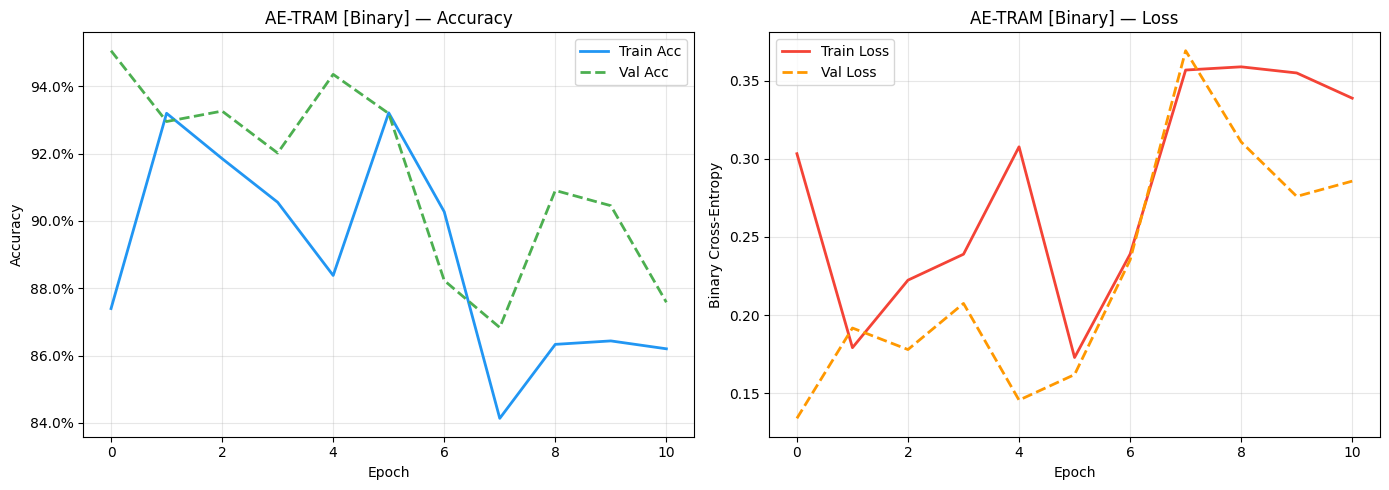

In [33]:
# ── Training curves — Binary ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(hist_binary.history['accuracy'],     label='Train Acc', color='#2196F3', lw=2)
ax1.plot(hist_binary.history['val_accuracy'], label='Val Acc',   color='#4CAF50', lw=2, ls='--')
ax1.set_title('AE-TRAM [Binary] — Accuracy', fontsize=12)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

ax2.plot(hist_binary.history['loss'],     label='Train Loss', color='#F44336', lw=2)
ax2.plot(hist_binary.history['val_loss'], label='Val Loss',   color='#FF9800', lw=2, ls='--')
ax2.set_title('AE-TRAM [Binary] — Loss', fontsize=12)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Binary Cross-Entropy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'tram_binary_training.png'), dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# ── Evaluate on test set — Binary ────────────────────────────────────────────
print('Evaluating TRAM on test set [Binary]...')
t0 = time.time()
raw_preds_bin = tram_binary.predict(X_test_enc, batch_size=TR_BATCH_SIZE, verbose=0)
inf_time_bin  = (time.time() - t0) / len(X_test_enc)

y_pred_bin = (raw_preds_bin.squeeze() > 0.5).astype(int)

acc_b  = accuracy_score(yb_test, y_pred_bin)
prec_b = precision_score(yb_test, y_pred_bin, zero_division=0)
rec_b  = recall_score(yb_test, y_pred_bin, zero_division=0)
f1_b   = f1_score(yb_test, y_pred_bin, zero_division=0)
mcc_b  = matthews_corrcoef(yb_test, y_pred_bin)
test_loss_b = tram_binary.evaluate(X_test_enc, yb_test,
                                    batch_size=TR_BATCH_SIZE, verbose=0)[0]

print('\n' + '='*58)
print('  AE-TRAM [BINARY] — Test Results')
print('='*58)
print(f'  Accuracy              : {acc_b*100:.4f}%')
print(f'  Precision             : {prec_b*100:.4f}%')
print(f'  Recall                : {rec_b*100:.4f}%')
print(f'  F1-Score              : {f1_b*100:.4f}%')
print(f'  MCC                   : {mcc_b:.4f}')
print(f'  Test Loss             : {test_loss_b:.4f}')
print(f'  Inference time/sample : {inf_time_bin:.6f}s')
print('='*58)

print('\nBinary Classification Report:')
print(classification_report(yb_test, y_pred_bin,
                             target_names=['BENIGN', 'ATTACK']))

Evaluating TRAM on test set [Binary]...

  AE-TRAM [BINARY] — Test Results
  Accuracy              : 95.0864%
  Precision             : 82.6528%
  Recall                : 89.7307%
  F1-Score              : 86.0464%
  MCC                   : 0.8317
  Test Loss             : 0.1338
  Inference time/sample : 0.000017s

Binary Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.98      0.96      0.97    419297
      ATTACK       0.83      0.90      0.86     85176

    accuracy                           0.95    504473
   macro avg       0.90      0.93      0.92    504473
weighted avg       0.95      0.95      0.95    504473



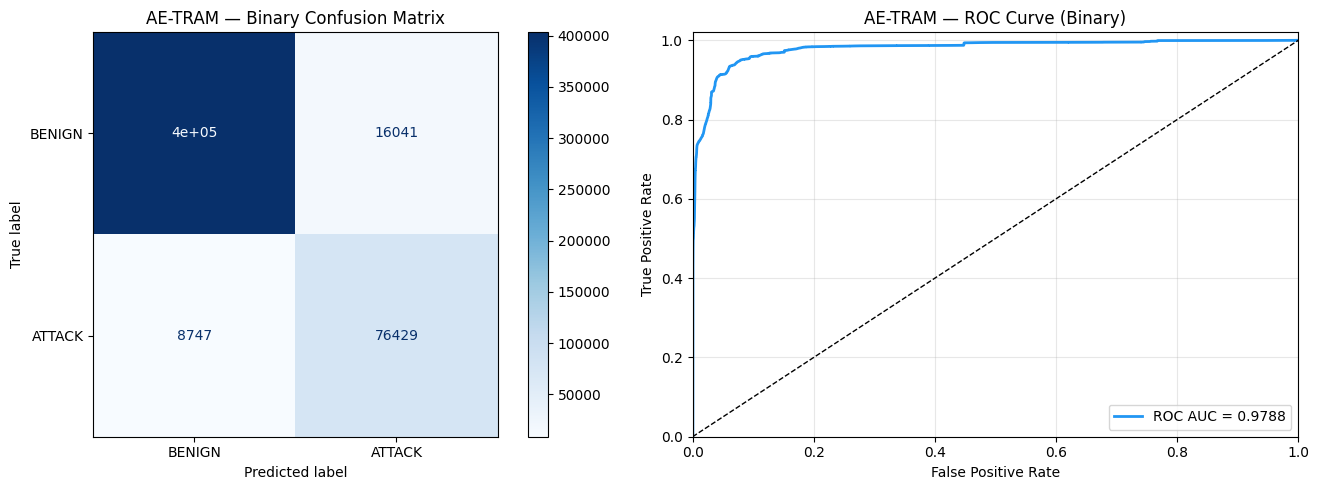

In [35]:
# ── Confusion Matrix — Binary ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm_bin = confusion_matrix(yb_test, y_pred_bin)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bin,
                               display_labels=['BENIGN', 'ATTACK'])
disp.plot(ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title('AE-TRAM — Binary Confusion Matrix')

# ROC curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(yb_test, raw_preds_bin.squeeze())
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#2196F3', lw=2,
             label=f'ROC AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('AE-TRAM — ROC Curve (Binary)')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'binary_cm_roc.png'), dpi=150, bbox_inches='tight')
plt.show()

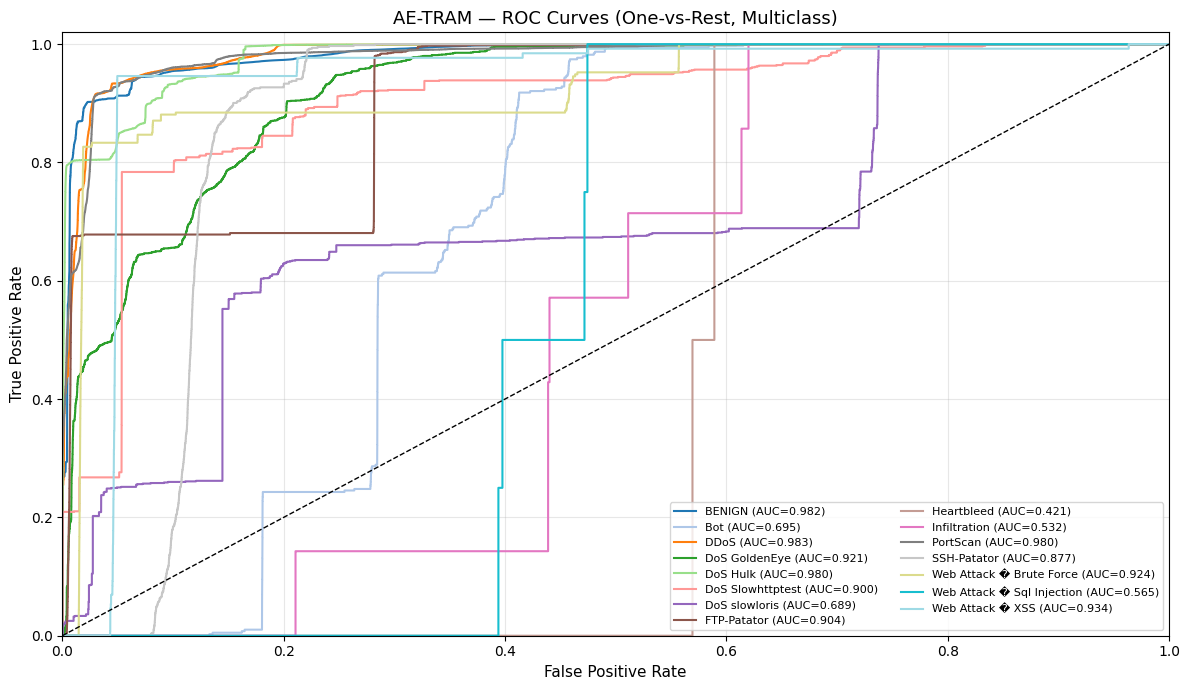

In [36]:
# ── ROC-AUC — Multiclass (one-vs-rest) ───────────────────────────────────────
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin_mc = label_binarize(ym_test, classes=list(range(n_classes)))

fig, ax = plt.subplots(figsize=(12, 7))
palette_roc = plt.cm.tab20(np.linspace(0, 1, n_classes))

for i, cname in enumerate(class_names):
    if y_test_bin_mc[:, i].sum() == 0:
        continue
    fpr_i, tpr_i, _ = roc_curve(y_test_bin_mc[:, i], raw_preds_multi[:, i])
    auc_i = auc(fpr_i, tpr_i)
    ax.plot(fpr_i, tpr_i, lw=1.5, color=palette_roc[i],
            label=f'{cname} (AUC={auc_i:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('AE-TRAM — ROC Curves (One-vs-Rest, Multiclass)', fontsize=13)
ax.legend(loc='lower right', fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'roc_multiclass.png'), dpi=150, bbox_inches='tight')
plt.show()

## 13. Final Summary & Comparison with AE-CIAM

In [37]:
# ── Summary Table ────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model'          : ['AE-CIAM (paper)', 'AE-TRAM (ours)', 'AE-CIAM (paper)', 'AE-TRAM (ours)'],
    'Task'           : ['Binary', 'Binary', 'Multiclass', 'Multiclass'],
    'Accuracy (%)'   : [99.99, acc_b*100, 99.44, acc_m*100],
    'Precision (%)'  : [99.99, prec_b*100, 99.08, prec_m*100],
    'Recall (%)'     : [99.99, rec_b*100, 99.44, rec_m*100],
    'F1-Score (%)'   : [99.99, f1_b*100, 99.26, f1_m*100],
    'Test Loss'      : [0.0246, test_loss_b, 0.0197, test_loss_m],
    'Inf. Time (s)'  : [0.000209, inf_time_bin, 0.000411, inf_time_multi],
    'Classifier'     : ['CNN Inception+Attn', 'Transformer Encoder',
                        'CNN Inception+Attn', 'Transformer Encoder'],
}).round(4)

print('\n' + '='*90)
print('  AE-TRAM vs AE-CIAM — Comparison Summary')
print('='*90)
print(summary.to_string(index=False))
print('='*90)

print('\n[Architecture Comparison]')
arch = pd.DataFrame({
    'Aspect'            : ['Classifier', 'Feature interaction', 'Positional info',
                           'Attention type', 'Params (classifier)', 'Parallelism'],
    'AE-CIAM'          : ['CNN Inception', 'Local (conv kernels)', 'Implicit',
                           'Scalar softmax', '15,624', 'Moderate'],
    'AE-TRAM'          : ['Transformer Encoder', 'Global (all-to-all)', 'Learned embeddings',
                           'Multi-Head (4 heads)', str(tram_multi.count_params()), 'High'],
})
print(arch.to_string(index=False))


  AE-TRAM vs AE-CIAM — Comparison Summary
          Model       Task  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  Test Loss  Inf. Time (s)          Classifier
AE-CIAM (paper)     Binary       99.9900        99.9900     99.9900       99.9900     0.0246         0.0002  CNN Inception+Attn
 AE-TRAM (ours)     Binary       95.0864        82.6528     89.7307       86.0464     0.1338         0.0000 Transformer Encoder
AE-CIAM (paper) Multiclass       99.4400        99.0800     99.4400       99.2600     0.0197         0.0004  CNN Inception+Attn
 AE-TRAM (ours) Multiclass       92.7830        92.4777     92.7830       92.4425     0.2506         0.0000 Transformer Encoder

[Architecture Comparison]
             Aspect              AE-CIAM              AE-TRAM
         Classifier        CNN Inception  Transformer Encoder
Feature interaction Local (conv kernels)  Global (all-to-all)
    Positional info             Implicit   Learned embeddings
     Attention type       Scalar softmax M

In [38]:
# ── LDDoS specific analysis ──────────────────────────────────────────────────
print('=== LDDoS Attack Detection Focus ===')
print(f'Target classes: {LDDOS_CLASSES}\n')

from sklearn.metrics import precision_recall_fscore_support
per_class_p, per_class_r, per_class_f, per_class_s = precision_recall_fscore_support(
    ym_test, y_pred_multi, zero_division=0
)

for cname in LDDOS_CLASSES:
    if cname in class_names:
        idx = class_names.index(cname)
        print(f'  {cname}:')
        print(f'    Precision : {per_class_p[idx]*100:.2f}%')
        print(f'    Recall    : {per_class_r[idx]*100:.2f}%')
        print(f'    F1-Score  : {per_class_f[idx]*100:.2f}%')
        print(f'    Support   : {per_class_s[idx]:,} samples')
        print()

=== LDDoS Attack Detection Focus ===
Target classes: ['DoS slowloris', 'DoS Slowhttptest']

  DoS slowloris:
    Precision : 0.00%
    Recall    : 0.00%
    F1-Score  : 0.00%
    Support   : 1,077 samples

  DoS Slowhttptest:
    Precision : 0.00%
    Recall    : 0.00%
    F1-Score  : 0.00%
    Support   : 1,046 samples



## 14. Save Models & Results

In [ ]:
# ── Save all trained models ───────────────────────────────────────────────────
ae_model.save(os.path.join(SAVE_DIR, 'ae_attention_model.keras'))
encoder_model.save(os.path.join(SAVE_DIR, 'encoder_model.keras'))
tram_multi.save(os.path.join(SAVE_DIR, 'tram_multiclass.keras'))
tram_binary.save(os.path.join(SAVE_DIR, 'tram_binary.keras'))

# Save results to CSV
results_df = pd.DataFrame({
    'Model': ['AE-TRAM'],
    'Binary_Accuracy': [acc_b*100],
    'Binary_Precision': [prec_b*100],
    'Binary_Recall': [rec_b*100],
    'Binary_F1': [f1_b*100],
    'Binary_MCC': [mcc_b],
    'Binary_TestLoss': [test_loss_b],
    'Binary_InfTime': [inf_time_bin],
    'Multi_Accuracy': [acc_m*100],
    'Multi_Precision': [prec_m*100],
    'Multi_Recall': [rec_m*100],
    'Multi_F1': [f1_m*100],
    'Multi_MCC': [mcc_m],
    'Multi_TestLoss': [test_loss_m],
    'Multi_InfTime': [inf_time_multi],
})
results_df.to_csv(os.path.join(SAVE_DIR, 'ae_tram_results.csv'), index=False)

print(f'Models and results saved to: {SAVE_DIR}/')
print('  ae_attention_model.keras')
print('  encoder_model.keras')
print('  tram_multiclass.keras')
print('  tram_binary.keras')
print('  ae_tram_results.csv')
print('  Plots: *.png')